In [3]:
import glob
import os
import requests
import json
import time
from pathlib import Path
import xarray as xr
from datetime import datetime
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc


#set current working directory
os.chdir('/home/jovyan')

#list files in shared folder
files = glob.glob("/shared_space/Galveston_Bay/*")

### log into earthdata

In [32]:
#directory we are working in  
destDir = os.getcwd()

#location for new files
dest_fp = "/shared_space/Galveston_Bay/MODIS_500"

if not os.path.exists(dest_fp):
    os.makedirs(dest_fp)

print("Exists?", os.path.exists(dest_fp))
print("Is directory?", os.path.isdir(dest_fp))

Exists? True
Is directory? True


In [33]:

#api link
API = "https://appeears.earthdatacloud.nasa.gov/api/"

#Earthdata Login credentials
username = 'mrfalk'
password = 'dataPlease12471!'

#token that is needed to get data
login_response = requests.post(
    f"{API}login",
    auth=(username, password)
)

if login_response.status_code != 200:
    raise Exception(f"Login failed: {login_response.text}")

token = login_response.json()['token']
headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {token}"
}

### explore available data

In [34]:
#this explores products available 
# request all products in the product service
product_response = requests.get('{}product'.format(API)).json()

# Create a dictionary indexed by product name & version           
products = {p['ProductAndVersion']: p for p in product_response}

#I think this is the product we will use for temperature 
product_name = 'MYD09GA.061' #MYD09A1.061  #MYD11A1.061 #MYD09GQ
products[product_name]  #this has measurements everyday, there is also a version with measurement ecery 8 days

{'Product': 'MYD09GA',
 'Platform': 'Aqua MODIS',
 'Description': 'Surface Reflectance Bands 1-7',
 'RasterType': 'Tile',
 'Resolution': '500/1000m',
 'TemporalGranularity': 'Daily',
 'Version': '061',
 'Available': True,
 'DocLink': 'https://doi.org/10.5067/MODIS/MYD09GA.061',
 'Source': 'LP DAAC',
 'TemporalExtentStart': '2002-07-04',
 'TemporalExtentEnd': 'Present',
 'Deleted': False,
 'DOI': '10.5067/MODIS/MYD09GA.061',
 'Info': {'provider_id': 'lp_prod'},
 'ProductAndVersion': 'MYD09GA.061'}

In [35]:
# Request layers for the 2nd product (index 1) in the list: MOD11A1.061
lst_response = requests.get('{}product/{}'.format(API,product_name)).json()
#shows available bands 
list(lst_response.keys()) 

['QC_500m_1',
 'Range_1',
 'SensorAzimuth_1',
 'SensorZenith_1',
 'SolarAzimuth_1',
 'SolarZenith_1',
 'gflags_1',
 'granule_pnt_1',
 'iobs_res_1',
 'num_observations_1km',
 'obscov_500m_1',
 'orbit_pnt_1',
 'state_1km_1',
 'sur_refl_b01_1',
 'sur_refl_b02_1',
 'sur_refl_b03_1',
 'sur_refl_b04_1',
 'sur_refl_b05_1',
 'sur_refl_b06_1',
 'sur_refl_b07_1']

### set up task

In [36]:
#Define bounding box as GeoJSON FeatureCollection
#chose bounding box based a frame that only required one block of earthdata
#this bounding box may not be the entire region that we want (it doesn't go very far north)
geo = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "geometry": {
                "type": "Polygon",
                "coordinates": [[
                    [-96.0, 28.5],
                    [-96.0, 30.0],
                    [-94.0, 30.0],
                    [-94.0, 28.5],
                    [-96.0, 28.5]
                ]]
            },
            "properties": {
                "name": "bbox_area"
            }
        }
    ]
}


In [37]:
#Define the HLS layer and product you want 
#layer comes from the lst_response

#here chose the emissivity bands for temperature
layers = [{'layer': 'sur_refl_b01_1', 'product': product_name},    
        {'layer': 'sur_refl_b02_1', 'product': product_name},
        {'layer': 'sur_refl_b03_1', 'product': product_name},
        {'layer': 'sur_refl_b04_1', 'product': product_name},
        {'layer': 'sur_refl_b05_1', 'product': product_name},
        {'layer': 'sur_refl_b06_1', 'product': product_name},
        {'layer': 'sur_refl_b07_1', 'product': product_name}]

    #{'layer': 'Emis_32', 'product':product_name}]



In [38]:
#Create the task the specifics what area to pull
task = {
    "task_type": "area",
    "task_name": "modis500_2020b1_2",
    "params": {
        "dates": [
            {
                "startDate": "01-01-2018",
                "endDate": "12-31-2018"
            }
        ],
        "layers": layers,
        "output": {
            "format": {"type": "geotiff"},
            "projection": "geographic"
        },
        "geo": geo
    }
}

#                 "startDate": "05-01-2017",
#                 "endDate": "08-31-2017"

The below code only needs to be run once- if unsure if the data downloaded, check https://appeears.earthdatacloud.nasa.gov/explore. This is where the requests are stored

In [39]:
#Submit the task
submit_response = requests.post(f"{API}task", headers=headers, json=task)

if submit_response.status_code != 202:
    raise Exception(f"Task submission failed: {submit_response.text}")

task_id = submit_response.json()['task_id']
print(f"Task submitted. ID: {task_id}")

# Check task status until it's done
while True:
    status_response = requests.get(f"{API}task/{task_id}", headers=headers)
    status_json = status_response.json()
    status = status_json['status']
    print(f"Task status: {status}")
    if status in ['done', 'failed']:
        break
    time.sleep(30)  # Wait 30 seconds between checks

if status == 'failed':
    raise Exception("Task failed.")


Task submitted. ID: b886694a-fb57-4b9d-876b-358c07bcf382
Task status: pending
Task status: pending
Task status: pending
Task status: pending
Task status: pending
Task status: pending
Task status: pending
Task status: pending
Task status: pending
Task status: pending
Task status: pending
Task status: pending
Task status: pending
Task status: pending
Task status: pending
Task status: pending
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task status: processing
Task st

KeyError: 'status'

The below code pulls the above task from the appears website and puts in a bundle (will need task id from the above code or from the website). Once it all runs once and you double check that it in the folder you want, do not run it again for it will duplicate files

In [181]:
#task_id = '320da34c-2cd8-4212-9802-7ca6c8ed365c'

In [182]:
#task_id

In [ ]:
# # Call API and return bundle contents for the task_id as json
bundle = requests.get('{}bundle/{}'.format(API,task_id), headers=headers).json()  
#bundle

In [ ]:
# build mapping once (your existing code) 
files = {f['file_id']: f['file_name'] for f in bundle['files']}

In [14]:
len(files)


2919

This code just double checks the path you want exists and that the files will actually go there

In [ ]:
dest_fp = "~/shared_space/Galveston_Bay/MODIS_500/bands2018"
# os.makedirs(dest_fp)
# #


# Expand ~ to your home directory
dest_fp = os.path.expanduser("~/shared_space/Galveston_Bay/MODIS_500/bands2020")

# Make sure the directory exists
os.makedirs(dest_fp, exist_ok=True)

print("Saving files to:", dest_fp)
# Check if the path exists
print("Exists:", os.path.exists(dest_fp))

# Check if it's a directory
print("Is directory:", os.path.isdir(dest_fp))

# Check if it's writable
print("Writable:", os.access(dest_fp, os.W_OK))

The code below will take the list of files and upload each one to the place you want it. the code chunk below runs for a long time if you have a lot files

In [18]:
for file_id, remote_name in files.items():
    url = f"{API}bundle/{task_id}/{file_id}"
    resp = requests.get(url, headers=headers, stream=True, allow_redirects=True, timeout=60)
    try:
        resp.raise_for_status()
    except Exception as e:
        print(f"Download failed for {remote_name}: {e}")
        continue

    # choose final filename (adjust logic if your names are nested)
    if remote_name.endswith('.tif'):
        filename = os.path.basename(remote_name)  # safer than split('/')[1]
    else:
        filename = remote_name

    filepath = os.path.join(dest_fp, filename)
    
    # write to disk in chunks
    with open(filepath, 'wb') as out_fh:
        for chunk in resp.iter_content(chunk_size=8192):
            if chunk:
                out_fh.write(chunk)

    print(f"Downloaded: {filepath}")

Downloaded: /home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_QC_500m_1_doy2020001000000_aid0001.tif
Downloaded: /home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_QC_500m_1_doy2020002000000_aid0001.tif
Downloaded: /home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_QC_500m_1_doy2020003000000_aid0001.tif
Downloaded: /home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_QC_500m_1_doy2020004000000_aid0001.tif
Downloaded: /home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_QC_500m_1_doy2020005000000_aid0001.tif
Downloaded: /home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_QC_500m_1_doy2020006000000_aid0001.tif
Downloaded: /home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_QC_500m_1_doy2020007000000_aid0001.tif
Downloaded: /home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_QC_500m_1_doy2020008000000_aid0001.tif
Downloaded: /hom

### Exploring data

Initial check

In [94]:
%%bash
gdalinfo /shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b02_1_doy2019195000000_aid0001.tif

Driver: GTiff/GeoTIFF
Files: /shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b02_1_doy2019195000000_aid0001.tif
Size is 961, 721
Coordinate System is:
GEOGCS["WGS 84",
    DATUM["WGS_1984",
        SPHEROID["WGS 84",6378137,298.257223563,
            AUTHORITY["EPSG","7030"]],
        AUTHORITY["EPSG","6326"]],
    PRIMEM["Greenwich",0],
    UNIT["degree",0.0174532925199433],
    AUTHORITY["EPSG","4326"]]
Origin = (-96.002083324732965,30.002083330645590)
Pixel Size = (0.002083333333147,-0.002083333333147)
Metadata:
  add_offset=0.0
  AREA_OR_POINT=Area
  scale_factor=0.0001
  units=Reflectance
Image Structure Metadata:
  COMPRESSION=LZW
  INTERLEAVE=BAND
Corner Coordinates:
Upper Left  ( -96.0020833,  30.0020833) ( 96d 0' 7.50"W, 30d 0' 7.50"N)
Lower Left  ( -96.0020833,  28.5000000) ( 96d 0' 7.50"W, 28d30' 0.00"N)
Upper Right ( -94.0000000,  30.0020833) ( 94d 0' 0.00"W, 30d 0' 7.50"N)
Lower Right ( -94.0000000,  28.5000000) ( 94d 0' 0.00"W, 28d30' 0.00"N)
Center      ( -9

pj_obj_create: Open of /opt/conda/share/proj failed


In [28]:
#this is all the 250m data for two surface reflectance bands
modis_files = glob.glob("/shared_space/Galveston_Bay/MODIS_files/*.tif")

In [46]:
fp_250 = modis_files[0]
fp_250

'/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b01_1_doy2019364000000_aid0001.tif'

In [37]:
test250 = rasterio.open(fp_250)
t_b1 = test250.read(1)
b1_ma = np.ma.masked_values(t_b1, -28672)
b1_ma.max()

2867

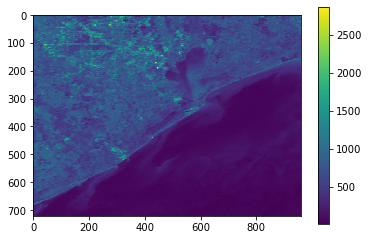

In [33]:
plt.imshow(b1_ma)
plt.colorbar()

## Now the data is in shared space and will go through Quality Control to get rid of clouds

Want to mask pixels that are cloudy in each day

In [71]:
#this function creates a mask for all cloudy pixel that can be applied to each day
#qc is the quality file
def decode_keep_mask(qc):
    # MODLAND bits 0-1
    modland = qc & 0b11
    
    # band1 quality bits 4-7 (shift then mask)
    band1_q = (qc >> 4) & 0b1111
    
    # band2 quality bits 8-11
    band2_q = (qc >> 8) & 0b1111
    
    # other single-bit flags
    atm_corr = (qc >> 12) & 0b1       # bit12
    adjacency = (qc >> 13) & 0b1      # bit13
    diff_orbit = (qc >> 14) & 0b1     # bit14

    # define problematic band-quality codes (decimal)
    bad_band_codes = {8,9,10,11,12,13,14,15}   # values from quality table to mask

    # Good if modland == 0 (00) and band1 & band2 are not in bad codes
    good_modland = (modland == 0)
    band1_ok = ~np.isin(band1_q, list(bad_band_codes))
    band2_ok = ~np.isin(band2_q, list(bad_band_codes))
    #atmosphere correction
    atm_ok = True
    
    # Keep pixel only if all criteria are met
    keep_mask = good_modland & band1_ok & band2_ok & atm_ok

    return keep_mask
    

In [96]:
file_dir = Path("/shared_space/Galveston_Bay/MODIS_files")
qc_files = sorted(file_dir.glob("*QC_250m*.tif"))

In [95]:
#creates a list of tuples that pair all the files in the same day for each tuple
all_files = []
for qc_file in qc_files:
    base = qc_file.name.replace("QC_250m_1", "sur_refl_b01_1") #band1 name
    b01 = qc_file.with_name(base) #band1 path
    b02 = qc_file.with_name(base.replace("b01", "b02")) #allows to check band2
    #double checks the file exist in the directory
    if b01.exists() and b02.exists():
        all_files.append((b01, b02, qc_file))


The output of all files is a list of tuples. Each tuple contains 3 file paths for the day that had good cloud cover. 

Create netcdf file for the year that contains both bands. Mask cloud cover when adding data to nc file

In [103]:
#need list of lat and lons that correspond to each pixel
test_fp = '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b01_1_doy2019001000000_aid0001.tif'
src = rasterio.open(test_fp)
b1 = src.read(1)
src.meta

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': -28672.0,
 'width': 961,
 'height': 721,
 'count': 1,
 'crs': CRS.from_epsg(4326),
 'transform': Affine(0.0020833333331466974, 0.0, -96.00208332473296,
        0.0, -0.0020833333331466974, 30.00208333064559)}

In [116]:
src.transform
width = src.width
height = src.height
x_origin = src.transform[2]
y_origin = src.transform[5]
x_step = src.transform[0]
y_step = src.transform[4]

latitudes = y_origin + np.arange(height) * y_step
longitudes = x_origin + np.arange(width) * x_step


In [136]:
dest_ncfp = "/shared_space/Galveston_Bay/MODIS_test/"
file = dest_ncfp+'surf_refl_250m_2019.nc'
os.system('rm -f %s' % file)
#Open the file as writable
fp = nc.Dataset(file,'w')

fp.createDimension('lat',size=len(latitudes))
fp.createDimension('lon',size=len(longitudes))
fp.createDimension('time',size=len(all_files))

#lat variable
lat_var = fp.createVariable('lat', 'f4', dimensions='lat')
lat_var[:] = latitudes

#lon variable
lon_var = fp.createVariable('lon', 'f4', dimensions='lon')
lon_var[:] = longitudes

#variable for band 1
var_b1 = fp.createVariable('sur_refl_b01', 'f4',dimensions=('time','lat','lon')) #zlib=True <- this made it run for a long time
var_b1.units = 'reflectance'
var_b1.missing_value = -28672
var_b1.scale_factor = 0.0001

#variable for band 2
var_b2 = fp.createVariable('sur_refl_b02', 'f4',dimensions=('time','lat','lon')) #zlib=True <- this made it run for a long time
var_b2.units = 'reflectance'
var_b2.missing_value = -28672
var_b2.scale_factor = 0.0001

#variable for time
time_var = fp.createVariable('time','f8',dimensions=('time'))
time_var.units = "days since 1970-01-01 00:00:00"
time_var.calendar = "gregorian"

#add data from reflectance files
for i, (b1_path, b2_path, qc_path) in enumerate(all_files):
    #open quality file to get cloud mask
    with rasterio.open(qc_path) as qc_src:
        qc_b = qc_src.read(1)
        cloud_mask = decode_keep_mask(qc_b)
    
    #band 1
    with rasterio.open(b1_path) as src:
        arr = src.read(1).astype(np.float32)
        #apply could mask
        arr[~cloud_mask] = -28672
        
    var_b1[i,:,:] = arr   # assign into the ith time slice    
    
    with rasterio.open(b2_path) as src:
        arr = src.read(1).astype(np.float32)
        #apply could mask
        arr[~cloud_mask] = -28672
        
    var_b2[i,:,:] = arr   # assign into the ith time slice
    
    # Parse DOY from filename
    doy_str = b1_path.name.split("_doy")[1][:7]   # e.g. '2019001'
    date = datetime.strptime(doy_str, "%Y%j")

    # Convert to "days since 1970-01-01"
    time_var[i] = (date - datetime(1970,1,1)).days
    
fp.close()

In [137]:
check_nc = xr.open_dataset('/shared_space/Galveston_Bay/MODIS_test/surf_refl_250m_2019.nc')
check_nc

<xarray.Dataset>
Dimensions:       (lat: 721, lon: 961, time: 365)
Coordinates:
  * lat           (lat) float32 30.002083 30.0 29.997917 ... 28.504168 28.502083
  * lon           (lon) float32 -96.00208 -96.0 ... -94.004166 -94.00208
  * time          (time) datetime64[ns] 2019-01-01 2019-01-02 ... 2019-12-31
Data variables:
    sur_refl_b01  (time, lat, lon) float32 ...
    sur_refl_b02  (time, lat, lon) float32 ...

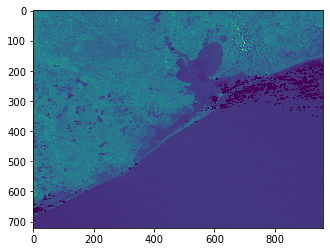

In [143]:
plt.imshow(check_nc['sur_refl_b01'].isel(time=110), vmin=0)
plt.imshow(check_nc['sur_refl_b02'].isel(time=110), vmin=0)

Repeat with 2020

In [155]:
#define path
file_dir = Path("/home/jovyan/shared_space/Galveston_Bay/MODIS_250")
qc_files = sorted(file_dir.glob("*QC_250m*.tif"))

In [156]:
#creates a list of tuples that pair all the files in the same day for each tuple
all_files = []
for qc_file in qc_files:
    base = qc_file.name.replace("QC_250m_1", "sur_refl_b01_1") #band1 name
    b01 = qc_file.with_name(base) #band1 path
    b02 = qc_file.with_name(base.replace("b01", "b02")) #allows to check band2
    #double checks the file exist in the directory
    if b01.exists() and b02.exists():
        all_files.append((b01, b02, qc_file))


In [160]:
#need list of lat and lons that correspond to each pixel
test_fp = '/home/jovyan/shared_space/Galveston_Bay/MODIS_250/MYD09GQ.061_sur_refl_b01_1_doy2020001000000_aid0001.tif'
src = rasterio.open(test_fp)
b1 = src.read(1)
src.meta

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': -28672.0,
 'width': 961,
 'height': 721,
 'count': 1,
 'crs': CRS.from_epsg(4326),
 'transform': Affine(0.0020833333331466974, 0.0, -96.00208332473296,
        0.0, -0.0020833333331466974, 30.00208333064559)}

In [161]:
src.transform
width = src.width
height = src.height
x_origin = src.transform[2]
y_origin = src.transform[5]
x_step = src.transform[0]
y_step = src.transform[4]

latitudes = y_origin + np.arange(height) * y_step
longitudes = x_origin + np.arange(width) * x_step


In [162]:
dest_ncfp = "/shared_space/Galveston_Bay/MODIS_test/"
file = dest_ncfp+'surf_refl_250m_2020.nc'
os.system('rm -f %s' % file)
#Open the file as writable
fp = nc.Dataset(file,'w')

fp.createDimension('lat',size=len(latitudes))
fp.createDimension('lon',size=len(longitudes))
fp.createDimension('time',size=len(all_files))

#lat variable
lat_var = fp.createVariable('lat', 'f4', dimensions='lat')
lat_var[:] = latitudes

#lon variable
lon_var = fp.createVariable('lon', 'f4', dimensions='lon')
lon_var[:] = longitudes

#variable for band 1
var_b1 = fp.createVariable('sur_refl_b01', 'f4',dimensions=('time','lat','lon')) #zlib=True <- this made it run for a long time
var_b1.units = 'reflectance'
var_b1.missing_value = -28672
var_b1.scale_factor = 0.0001

#variable for band 2
var_b2 = fp.createVariable('sur_refl_b02', 'f4',dimensions=('time','lat','lon')) #zlib=True <- this made it run for a long time
var_b2.units = 'reflectance'
var_b2.missing_value = -28672
var_b2.scale_factor = 0.0001

#variable for time
time_var = fp.createVariable('time','f8',dimensions=('time'))
time_var.units = "days since 1970-01-01 00:00:00"
time_var.calendar = "gregorian"

#add data from reflectance files
for i, (b1_path, b2_path, qc_path) in enumerate(all_files):
    #open quality file to get cloud mask
    with rasterio.open(qc_path) as qc_src:
        qc_b = qc_src.read(1)
        cloud_mask = decode_keep_mask(qc_b)
    
    #band 1
    with rasterio.open(b1_path) as src:
        arr = src.read(1).astype(np.float32)
        #apply could mask
        arr[~cloud_mask] = -28672
        
    var_b1[i,:,:] = arr   # assign into the ith time slice    
    
    with rasterio.open(b2_path) as src:
        arr = src.read(1).astype(np.float32)
        #apply could mask
        arr[~cloud_mask] = -28672
        
    var_b2[i,:,:] = arr   # assign into the ith time slice
    
    # Parse DOY from filename
    doy_str = b1_path.name.split("_doy")[1][:7]   # e.g. '2019001'
    date = datetime.strptime(doy_str, "%Y%j")

    # Convert to "days since 1970-01-01"
    time_var[i] = (date - datetime(1970,1,1)).days
    
fp.close()

In [163]:
check_nc2 = xr.open_dataset('/shared_space/Galveston_Bay/MODIS_test/surf_refl_250m_2020.nc')
check_nc2

<xarray.Dataset>
Dimensions:       (lat: 721, lon: 961, time: 364)
Coordinates:
  * lat           (lat) float32 30.002083 30.0 29.997917 ... 28.504168 28.502083
  * lon           (lon) float32 -96.00208 -96.0 ... -94.004166 -94.00208
  * time          (time) datetime64[ns] 2020-01-01 2020-01-02 ... 2020-12-31
Data variables:
    sur_refl_b01  (time, lat, lon) float32 ...
    sur_refl_b02  (time, lat, lon) float32 ...

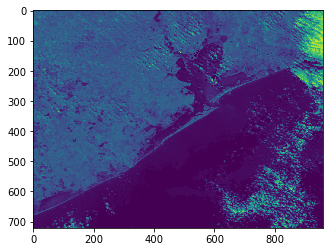

In [168]:
plt.imshow(check_nc2['sur_refl_b01'].isel(time=10), vmin=0)
plt.imshow(check_nc2['sur_refl_b02'].isel(time=10), vmin=0)

500m resolution bands 1-7

In [26]:
#quality control to mask cloudy pixels
def decode_keep_mask(qc):
    # MODLAND QA bits (bits 0–1)
    modland = qc & 0b11
    good_modland = (modland == 0)

    # Band quality bits (bits 2–8)
    band_quality_bits = [(qc >> b) & 0b1 for b in range(2, 9)]
    bands_ok = np.all(np.array(band_quality_bits) == 0, axis=0)

    # Additional flags (optional but recommended)
    data_fill = (qc >> 9) & 0b1         # Bit 9: data fill flag (0 = valid)
    cloud_flag = (qc >> 10) & 0b1       # Bit 10: cloud flag (0 = clear)
    cloud_shadow = (qc >> 15) & 0b1     # Bit 15: cloud shadow flag (0 = no shadow)

    no_data_fill = (data_fill == 0)
    no_cloud = (cloud_flag == 0)
    no_shadow = (cloud_shadow == 0)

    # Final mask
    keep_mask = good_modland & bands_ok & no_data_fill & no_cloud & no_shadow

    return keep_mask

In [195]:
#define path
file_dir = Path("/home/jovyan/shared_space/Galveston_Bay/MODIS_500")
qc_files = sorted(file_dir.glob("*QC_500m*.tif"))

In [200]:
all_files = []
for qc_file in qc_files:
    # Start with band 1 filename
    base = qc_file.name.replace("QC_500m_1", "sur_refl_b01_1")
    band_paths = []

    # Generate paths for bands 1 through 7
    for b in range(1, 8):
        band_name = base.replace("b01", f"b{b:02d}")
        band_path = qc_file.with_name(band_name)
        band_paths.append(band_path)

    # Check that all band files exist
    if all(p.exists() for p in band_paths):
        all_files.append((*band_paths, qc_file))  # unpack band_paths into tuple


In [202]:
all_files[0]

(PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/MYD09GA.061_sur_refl_b01_1_doy2019001000000_aid0001.tif'),
 PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/MYD09GA.061_sur_refl_b02_1_doy2019001000000_aid0001.tif'),
 PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/MYD09GA.061_sur_refl_b03_1_doy2019001000000_aid0001.tif'),
 PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/MYD09GA.061_sur_refl_b04_1_doy2019001000000_aid0001.tif'),
 PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/MYD09GA.061_sur_refl_b05_1_doy2019001000000_aid0001.tif'),
 PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/MYD09GA.061_sur_refl_b06_1_doy2019001000000_aid0001.tif'),
 PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/MYD09GA.061_sur_refl_b07_1_doy2019001000000_aid0001.tif'),
 PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/MYD09GA.061_QC_500m_1_doy2019001000000_aid0001.tif'))

In [204]:
#need list of lat and lons that correspond to each pixel
test_fp = '/home/jovyan/shared_space/Galveston_Bay/MODIS_500/MYD09GA.061_sur_refl_b01_1_doy2019001000000_aid0001.tif'
src = rasterio.open(test_fp)
b1 = src.read(1)
src.meta

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': -28672.0,
 'width': 481,
 'height': 361,
 'count': 1,
 'crs': CRS.from_epsg(4326),
 'transform': Affine(0.004166666666293395, 0.0, -96.00416665806611,
        0.0, -0.004166666666293395, 30.004166663978737)}

In [205]:
src.transform
width = src.width
height = src.height
x_origin = src.transform[2]
y_origin = src.transform[5]
x_step = src.transform[0]
y_step = src.transform[4]

latitudes = y_origin + np.arange(height) * y_step
longitudes = x_origin + np.arange(width) * x_step

In [208]:
dest_ncfp = "/shared_space/Galveston_Bay/MODIS_test/"
file = dest_ncfp + 'surf_refl_500m_2019.nc'
os.system('rm -f %s' % file)

# Open the file as writable
fp = nc.Dataset(file, 'w')

# Dimensions
fp.createDimension('lat', size=len(latitudes))
fp.createDimension('lon', size=len(longitudes))
fp.createDimension('time', size=len(all_files))

# Latitude variable
lat_var = fp.createVariable('lat', 'f4', dimensions=('lat',))
lat_var[:] = latitudes

# Longitude variable
lon_var = fp.createVariable('lon', 'f4', dimensions=('lon',))
lon_var[:] = longitudes

# Create variables for 7 bands dynamically
band_vars = {}
for b in range(1, 8):
    var_name = f'sur_refl_b{b:02d}'   # e.g. sur_refl_b01, sur_refl_b02, ...
    band_vars[var_name] = fp.createVariable(var_name, 'f4', dimensions=('time','lat','lon'))
    band_vars[var_name].units = 'reflectance'
    band_vars[var_name].missing_value = -28672
    band_vars[var_name].scale_factor = 0.0001

# Time variable
time_var = fp.createVariable('time', 'f8', dimensions=('time',))
time_var.units = "days since 1970-01-01 00:00:00"
time_var.calendar = "gregorian"

# Add data from reflectance files
for i, (*band_paths, qc_path) in enumerate(all_files):
    # open quality file to get cloud mask
    with rasterio.open(qc_path) as qc_src:
        qc_b = qc_src.read(1)
        cloud_mask = decode_keep_mask(qc_b)

    # loop through all 7 bands
    for b, band_path in enumerate(band_paths, start=1):
        with rasterio.open(band_path) as src:
            arr = src.read(1).astype(np.float32)
            arr[~cloud_mask] = -28672
        var_name = f'sur_refl_b{b:02d}'
        band_vars[var_name][i, :, :] = arr

    # Parse DOY from filename (use band1 path as reference)
    doy_str = band_paths[0].name.split("_doy")[1][:7]   # e.g. '2019001'
    date = datetime.strptime(doy_str, "%Y%j")
    time_var[i] = (date - datetime(1970,1,1)).days

fp.close()


In [215]:
file

'/shared_space/Galveston_Bay/MODIS_test/surf_refl_500m_2019.nc'

In [210]:
check_nc3 = xr.open_dataset('/shared_space/Galveston_Bay/MODIS_test/surf_refl_500m_2019.nc')
check_nc3

<xarray.Dataset>
Dimensions:       (lat: 361, lon: 481, time: 365)
Coordinates:
  * lat           (lat) float32 30.004168 30.0 29.995832 ... 28.508333 28.504168
  * lon           (lon) float32 -96.004166 -96.0 ... -94.00833 -94.004166
  * time          (time) datetime64[ns] 2019-01-01 2019-01-02 ... 2019-12-31
Data variables:
    sur_refl_b01  (time, lat, lon) float32 ...
    sur_refl_b02  (time, lat, lon) float32 ...
    sur_refl_b03  (time, lat, lon) float32 ...
    sur_refl_b04  (time, lat, lon) float32 ...
    sur_refl_b05  (time, lat, lon) float32 ...
    sur_refl_b06  (time, lat, lon) float32 ...
    sur_refl_b07  (time, lat, lon) float32 ...

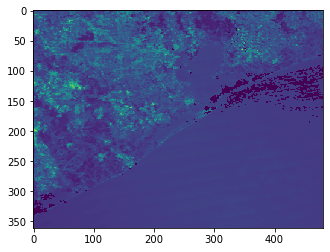

In [214]:
plt.imshow(check_nc3['sur_refl_b01'].isel(time=110), vmin=0)
plt.imshow(check_nc3['sur_refl_b02'].isel(time=110), vmin=0)
plt.imshow(check_nc3['sur_refl_b03'].isel(time=110), vmin=0)
plt.imshow(check_nc3['sur_refl_b04'].isel(time=110), vmin=0)
plt.imshow(check_nc3['sur_refl_b05'].isel(time=110), vmin=0)
plt.imshow(check_nc3['sur_refl_b06'].isel(time=110), vmin=0)
plt.imshow(check_nc3['sur_refl_b07'].isel(time=110), vmin=0)

Same for 2020!

In [19]:
#define path
file_dir = Path("/home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020")
qc_files = sorted(file_dir.glob("*QC_500m*.tif"))

In [21]:
all_files = []
for qc_file in qc_files:
    # Start with band 1 filename
    base = qc_file.name.replace("QC_500m_1", "sur_refl_b01_1")
    band_paths = []

    # Generate paths for bands 1 through 7
    for b in range(1, 8):
        band_name = base.replace("b01", f"b{b:02d}")
        band_path = qc_file.with_name(band_name)
        band_paths.append(band_path)

    # Check that all band files exist
    if all(p.exists() for p in band_paths):
        all_files.append((*band_paths, qc_file))  # unpack band_paths into tuple


In [22]:
all_files[0]

(PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_sur_refl_b01_1_doy2020001000000_aid0001.tif'),
 PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_sur_refl_b02_1_doy2020001000000_aid0001.tif'),
 PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_sur_refl_b03_1_doy2020001000000_aid0001.tif'),
 PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_sur_refl_b04_1_doy2020001000000_aid0001.tif'),
 PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_sur_refl_b05_1_doy2020001000000_aid0001.tif'),
 PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_sur_refl_b06_1_doy2020001000000_aid0001.tif'),
 PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_sur_refl_b07_1_doy2020001000000_aid0001.tif'),
 PosixPath('/home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061

In [23]:
#need list of lat and lons that correspond to each pixel
test_fp = '/home/jovyan/shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_sur_refl_b01_1_doy2020001000000_aid0001.tif'
src = rasterio.open(test_fp)
b1 = src.read(1)
src.meta

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': -28672.0,
 'width': 481,
 'height': 361,
 'count': 1,
 'crs': CRS.from_epsg(4326),
 'transform': Affine(0.004166666666293395, 0.0, -96.00416665806611,
        0.0, -0.004166666666293395, 30.004166663978737)}

In [24]:
src.transform
width = src.width
height = src.height
x_origin = src.transform[2]
y_origin = src.transform[5]
x_step = src.transform[0]
y_step = src.transform[4]

latitudes = y_origin + np.arange(height) * y_step
longitudes = x_origin + np.arange(width) * x_step

In [27]:
dest_ncfp = "/shared_space/Galveston_Bay/MODIS_test/"
file = dest_ncfp + 'surf_refl_500m_2020.nc'
os.system('rm -f %s' % file)

# Open the file as writable
fp = nc.Dataset(file, 'w')

# Dimensions
fp.createDimension('lat', size=len(latitudes))
fp.createDimension('lon', size=len(longitudes))
fp.createDimension('time', size=len(all_files))

# Latitude variable
lat_var = fp.createVariable('lat', 'f4', dimensions=('lat',))
lat_var[:] = latitudes

# Longitude variable
lon_var = fp.createVariable('lon', 'f4', dimensions=('lon',))
lon_var[:] = longitudes

# Create variables for 7 bands dynamically
band_vars = {}
for b in range(1, 8):
    var_name = f'sur_refl_b{b:02d}'   # e.g. sur_refl_b01, sur_refl_b02, ...
    band_vars[var_name] = fp.createVariable(var_name, 'f4', dimensions=('time','lat','lon'))
    band_vars[var_name].units = 'reflectance'
    band_vars[var_name].missing_value = -28672
    band_vars[var_name].scale_factor = 0.0001

# Time variable
time_var = fp.createVariable('time', 'f8', dimensions=('time',))
time_var.units = "days since 1970-01-01 00:00:00"
time_var.calendar = "gregorian"

# Add data from reflectance files
for i, (*band_paths, qc_path) in enumerate(all_files):
    # open quality file to get cloud mask
    with rasterio.open(qc_path) as qc_src:
        qc_b = qc_src.read(1)
        cloud_mask = decode_keep_mask(qc_b)

    # loop through all 7 bands
    for b, band_path in enumerate(band_paths, start=1):
        with rasterio.open(band_path) as src:
            arr = src.read(1).astype(np.float32)
            arr[~cloud_mask] = -28672
        var_name = f'sur_refl_b{b:02d}'
        band_vars[var_name][i, :, :] = arr

    # Parse DOY from filename (use band1 path as reference)
    doy_str = band_paths[0].name.split("_doy")[1][:7]   # e.g. '2019001'
    date = datetime.strptime(doy_str, "%Y%j")
    time_var[i] = (date - datetime(1970,1,1)).days

fp.close()


In [2]:
check_nc4 = xr.open_dataset('/shared_space/Galveston_Bay/MODIS_test/surf_refl_500m_2020.nc')
check_nc4

<xarray.Dataset>
Dimensions:       (lat: 361, lon: 481, time: 364)
Coordinates:
  * lat           (lat) float32 30.004168 30.0 29.995832 ... 28.508333 28.504168
  * lon           (lon) float32 -96.004166 -96.0 ... -94.00833 -94.004166
  * time          (time) datetime64[ns] 2020-01-01 2020-01-02 ... 2020-12-31
Data variables:
    sur_refl_b01  (time, lat, lon) float32 ...
    sur_refl_b02  (time, lat, lon) float32 ...
    sur_refl_b03  (time, lat, lon) float32 ...
    sur_refl_b04  (time, lat, lon) float32 ...
    sur_refl_b05  (time, lat, lon) float32 ...
    sur_refl_b06  (time, lat, lon) float32 ...
    sur_refl_b07  (time, lat, lon) float32 ...

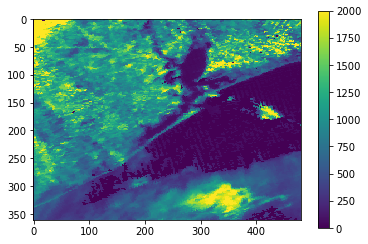

In [11]:
plt.imshow(check_nc4['sur_refl_b01'].isel(time=110), vmin=0, vmax =2000)
plt.imshow(check_nc4['sur_refl_b02'].isel(time=110), vmin=0, vmax =2000)
plt.imshow(check_nc4['sur_refl_b03'].isel(time=110), vmin=0, vmax =2000)
plt.imshow(check_nc4['sur_refl_b04'].isel(time=110), vmin=0, vmax =2000)
plt.imshow(check_nc4['sur_refl_b05'].isel(time=110), vmin=0, vmax =2000)
plt.imshow(check_nc4['sur_refl_b06'].isel(time=110), vmin=0, vmax =2000)
plt.imshow(check_nc4['sur_refl_b07'].isel(time=110), vmin=0, vmax =2000)
plt.colorbar()

Want to combine into one net cdf file

In [5]:
#open all datasets
#500m bands
# check_nc4 = xr.open_dataset('/shared_space/Galveston_Bay/MODIS_test/surf_refl_500m_2020.nc')
# check_nc3 = xr.open_dataset('/shared_space/Galveston_Bay/MODIS_test/surf_refl_500m_2019.nc')

#250m bands
check_nc2 = xr.open_dataset('/shared_space/Galveston_Bay/MODIS_test/surf_refl_250m_2020.nc')
check_nc = xr.open_dataset('/shared_space/Galveston_Bay/MODIS_test/surf_refl_250m_2019.nc')

In [ ]:
# Combine along time (xarray auto-detects the dimension)
combined = xr.merge([check_nc, check_nc2])

In [ ]:
print('test')

Below is old code

In [71]:
# # Expand ~ first
# dest_fp = os.path.expanduser("~/shared_space/Galveston_Bay/MODIS_test")

# # Create the directory if it doesn't exist
# os.makedirs(dest_fp, exist_ok=True)

# # Check properties
# print("Exists:", os.path.exists(dest_fp))
# print("Is directory:", os.path.isdir(dest_fp))
# print("Writable:", os.access(dest_fp, os.W_OK))
# print("Saving files to:", dest_fp)

# try:
#     test_path = os.path.join(dest_fp, "write_test.tmp")
#     with open(test_path, "w") as f:
#         f.write("test")
#     os.remove(test_path)
#     print("Write test succeeded.")
# except Exception as e:
#     print("Write test failed:", e)


Exists: True
Is directory: True
Writable: True
Saving files to: /home/jovyan/shared_space/Galveston_Bay/MODIS_test
Write test succeeded.


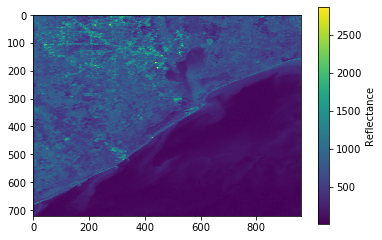

In [55]:
# #test to see if it is the same as before put into netcdf
# data = t['sur_refl_b01'][319,:,:]   # first time slice (day 0)
# data_m = np.ma.masked_values(data, -28672)

# plt.imshow(data_m, cmap='viridis')
# plt.colorbar(label='Reflectance')
# plt.show()

Same netCDF creation for 2020. I'm realizing after the fact that we probably want the amount of data/the days of data to be the same for each year? The below code finds the 'good' files for 2020, which are a different set of dates than 2019.

In [148]:
# #doing the same for 2020
# # Find all QC files
# file_dir = Path("/home/jovyan/shared_space/Galveston_Bay/MODIS_250")
# qc_files = sorted(file_dir.glob("*QC_250m*.tif"))

# #function that will compute how much of image is clear
# def compute_clear_fraction(qc_path):
#     with rasterio.open(qc_path) as src:
#         qc = src.read(1)
#     # decode bits 0-2
#     modland_bits = (qc & 0b11)             # bits 0–1
#     cloud_state  = (qc >> 2) & 0b1         # bit 2
#     # “Clear” pixels: modland_bits==0 (good) AND cloud_state==0 (clear)
#     clear_mask = (modland_bits == 0) & (cloud_state == 0)
#     valid_pixels = np.isfinite(qc)
#     clear_fraction = clear_mask.sum() / valid_pixels.sum()
#     return clear_fraction

# # threshold for acceptable cloud cover
# cloud_threshold = 0.70  # keep files with >70% clear pixels

In [150]:
# good_files = []
# for qc_file in qc_files:
#     frac = compute_clear_fraction(qc_file)
#     #print(qc_file.name, f"{frac:.2%} clear")
#     if frac > cloud_threshold:
#         # link to the corresponding surface reflectance bands
#         base = qc_file.name.replace("QC_250m_1", "sur_refl_b01_1") #allows check band1
#         b01 = qc_file.with_name(base)
#         b02 = qc_file.with_name(base.replace("b01", "b02")) #allows to check band2
#         #double checks the file exist in the directory
#         if b01.exists() and b02.exists():
#             good_files.append((b01, b02, qc_file))

# print(f"\nFound {len(good_files)} mostly-clear scenes out of {len(qc_files)} total.")


Found 335 mostly-clear scenes out of 364 total.


In [85]:
# #band 1
# file = '/home/jovyan/shared_space/Galveston_Bay/MODIS_test/sur_refl_b1_2020.nc'
# os.system('rm -f %s' % file)
# #Open the file as writable
# fp = nc.Dataset(file,'w')

# #make variable for lat and lon
# fp.createDimension('x',size=sample.shape[1])
# fp.createDimension('y',size=sample.shape[0])
# fp.createDimension('time',size=len(good_files))

# var = fp.createVariable('sur_refl_b01', 'f4',dimensions=('time','y','x'))
# var.units = 'reflectance'
# var.missing_value = -28672
# var.scale_factor = 0.0001

# time_var = fp.createVariable('time','f8',dimensions=('time'))
# time_var.units = "days since 1970-01-01 00:00:00"
# time_var.calendar = "gregorian"


# for i, (b1_path, b2_path, qc_path) in enumerate(good_files):
#     with rasterio.open(b1_path) as src:
#         arr = src.read(1).astype(np.float32)
#     var[i,:,:] = arr   # assign into the ith time slice
    
#     # Parse DOY from filename
#     doy_str = b1_path.name.split("_doy")[1][:7]   # e.g. '2019001'
#     date = datetime.strptime(doy_str, "%Y%j")

#     # Convert to "days since 1970-01-01"
#     time_var[i] = (date - datetime(1970,1,1)).days
    
# fp.close()

Combining 500m surface reflectance bands 1-7